# NAME - *Hitesh Girish Deore*
# ROLL NO - 2505

# Assignment:-1
# Simulation and Statistical Distributions using Python

$Q1)$

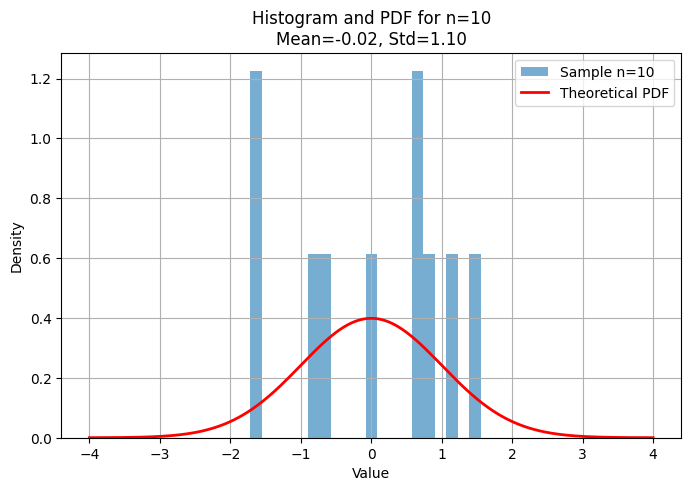

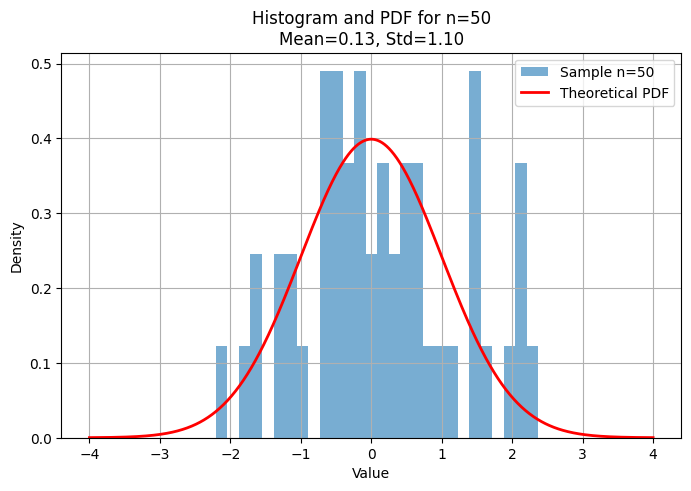

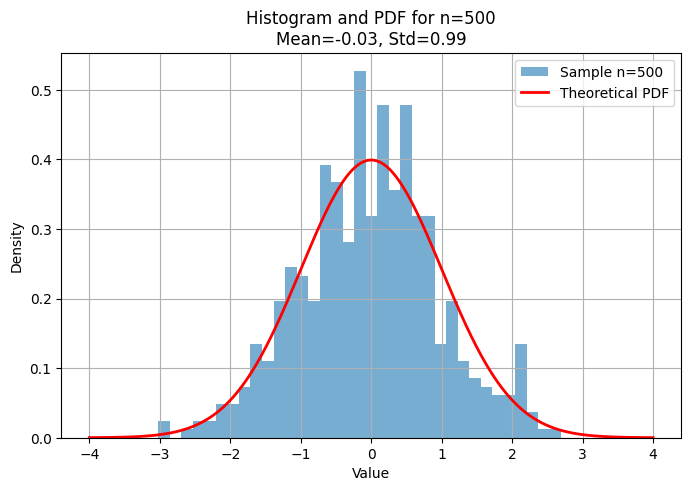

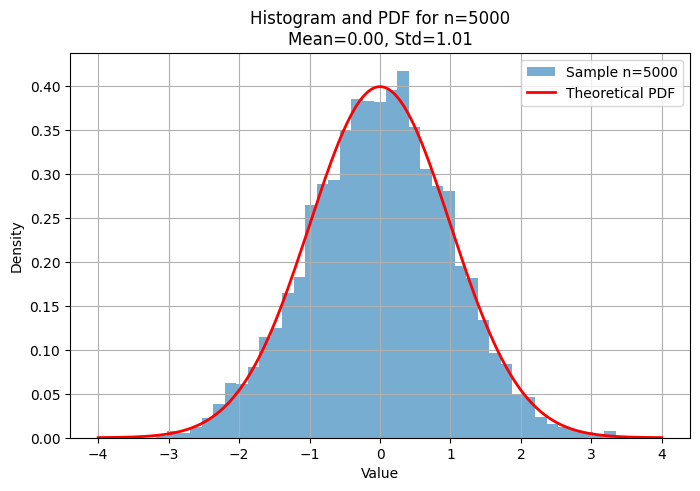

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
mu = 0
sigma = 1
sample_sizes = [10, 50, 500, 5000]
bins = np.linspace(-4, 4, 50)

# Plot settings
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)

# Generate and plot
for n in sample_sizes:
    sample = np.random.normal(mu, sigma, n)
    sample_mean = np.mean(sample)
    sample_std = np.std(sample)

    plt.hist(sample, bins=bins, density=True, alpha=0.6, label=f"Sample n={n}")
    x = np.linspace(-4, 4, 1000)
    plt.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2, label="Theoretical PDF")
    plt.title(f"Histogram and PDF for n={n}\nMean={sample_mean:.2f}, Std={sample_std:.2f}")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()

$Q2)$

In [3]:
import numpy as np
from scipy.stats import expon

# Step 1: Generate sample and estimate rate
sample = np.random.exponential(scale=1.0, size=10000)
estimated_lambda = 1 / np.mean(sample)
print(f"Estimated rate (λ): {estimated_lambda:.4f}")

# Step 2: Empirical memoryless property
s, t = 2, 3
empirical_conditional = np.mean(sample > s + t) / np.mean(sample > s)
empirical_direct = np.mean(sample > t)
print(f"P(X > s + t | X > s): {empirical_conditional:.4f}")
print(f"P(X > t): {empirical_direct:.4f}")

# Step 3: Theoretical comparison
theoretical_conditional = expon.sf(s + t, scale=1/estimated_lambda) / expon.sf(s, scale=1/estimated_lambda)
theoretical_direct = expon.sf(t, scale=1/estimated_lambda)
print(f"Theoretical P(X > s + t | X > s): {theoretical_conditional:.4f}")
print(f"Theoretical P(X > t): {theoretical_direct:.4f}")


Estimated rate (λ): 0.9973
P(X > s + t | X > s): 0.0515
P(X > t): 0.0491
Theoretical P(X > s + t | X > s): 0.0502
Theoretical P(X > t): 0.0502


$Q3)$

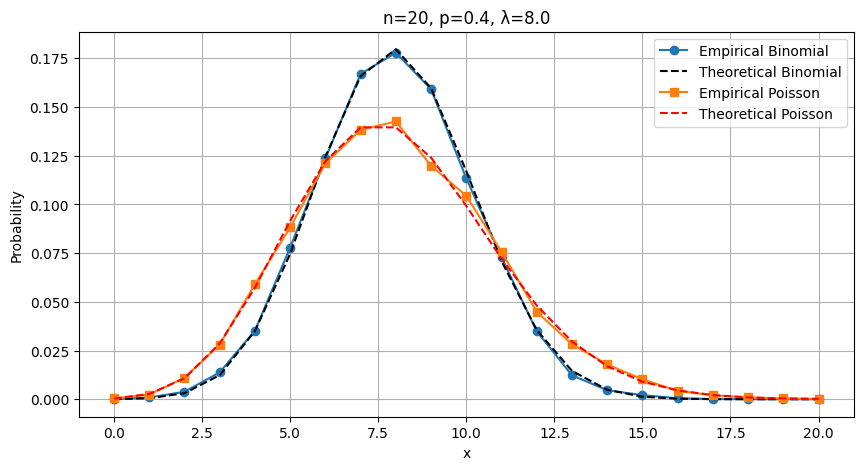

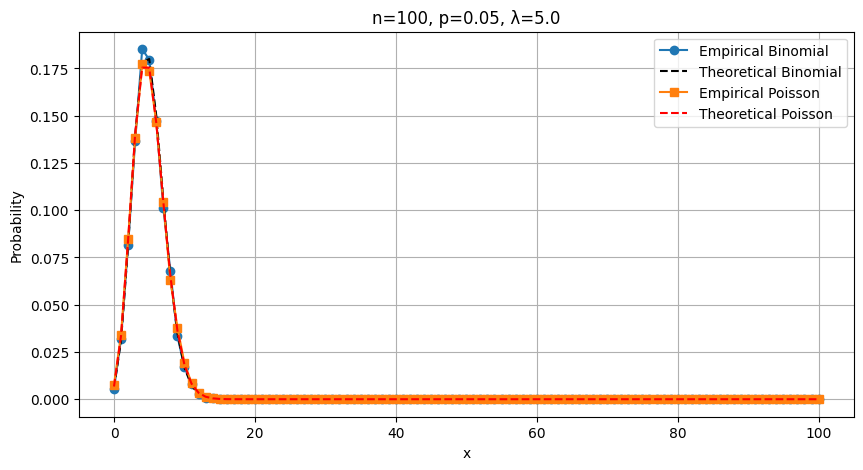

In [4]:
import matplotlib.pyplot as plt
from scipy.stats import binom, poisson

# Parameters
params = [(20, 0.4), (100, 0.05)]

for n, p in params:
    lam = n * p
    x = np.arange(0, n + 1)

    # Generate samples
    binom_sample = np.random.binomial(n, p, size=10000)
    poisson_sample = np.random.poisson(lam, size=10000)

    # Empirical PMFs
    binom_counts = np.bincount(binom_sample, minlength=n+1) / len(binom_sample)
    poisson_counts = np.bincount(poisson_sample, minlength=n+1) / len(poisson_sample)

    # Theoretical PMFs
    binom_pmf = binom.pmf(x, n, p)
    poisson_pmf = poisson.pmf(x, lam)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(x, binom_counts, 'o-', label='Empirical Binomial')
    plt.plot(x, binom_pmf, 'k--', label='Theoretical Binomial')
    plt.plot(x, poisson_counts, 's-', label='Empirical Poisson')
    plt.plot(x, poisson_pmf, 'r--', label='Theoretical Poisson')
    plt.title(f'n={n}, p={p}, λ={lam}')
    plt.xlabel('x')
    plt.ylabel('Probability')
    plt.legend()
    plt.grid(True)
    plt.show()


$Q4)$

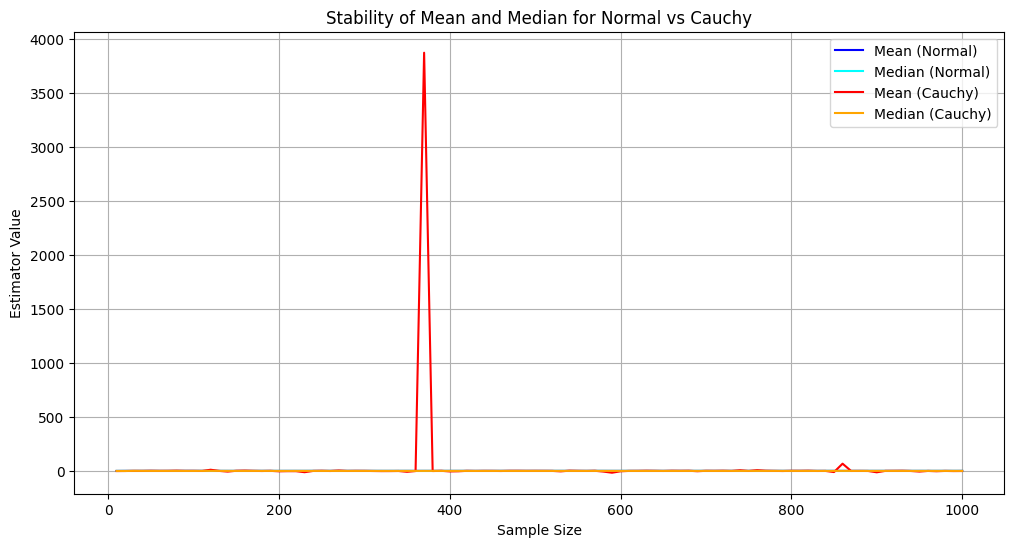

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Sample sizes
sample_sizes = np.arange(10, 1001, 10)
mean_normal = []
median_normal = []
mean_cauchy = []
median_cauchy = []

for size in sample_sizes:
    normal_sample = np.random.normal(loc=0, scale=1, size=size)
    cauchy_sample = np.random.standard_cauchy(size=size)

    mean_normal.append(np.mean(normal_sample))
    median_normal.append(np.median(normal_sample))
    mean_cauchy.append(np.mean(cauchy_sample))
    median_cauchy.append(np.median(cauchy_sample))

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(sample_sizes, mean_normal, label='Mean (Normal)', color='blue')
plt.plot(sample_sizes, median_normal, label='Median (Normal)', color='cyan')
plt.plot(sample_sizes, mean_cauchy, label='Mean (Cauchy)', color='red')
plt.plot(sample_sizes, median_cauchy, label='Median (Cauchy)', color='orange')
plt.xlabel('Sample Size')
plt.ylabel('Estimator Value')
plt.title('Stability of Mean and Median for Normal vs Cauchy')
plt.legend()
plt.grid(True)
plt.show()


$Q5)$

In [6]:
from scipy.stats import gamma

# Generate sample
shape_true, scale_true = 2.0, 3.0
sample = np.random.gamma(shape=shape_true, scale=scale_true, size=10000)

# Method of Moments
sample_mean = np.mean(sample)
sample_var = np.var(sample)
shape_mom = sample_mean**2 / sample_var
scale_mom = sample_var / sample_mean
print(f"Method of Moments: shape={shape_mom:.4f}, scale={scale_mom:.4f}")

# Quantile-based Estimation
q1, q2, q3 = np.percentile(sample, [25, 50, 75])
def estimate_from_quantiles(q1, q2, q3):
    # Use median and IQR to estimate shape and scale heuristically
    iqr = q3 - q1
    scale_est = iqr / 2  # rough approximation
    shape_est = q2 / scale_est
    return shape_est, scale_est

shape_quant, scale_quant = estimate_from_quantiles(q1, q2, q3)
print(f"Quantile-based Estimation: shape={shape_quant:.4f}, scale={scale_quant:.4f}")


Method of Moments: shape=1.9533, scale=3.0615
Quantile-based Estimation: shape=1.9474, scale=2.5662


$Q6)$

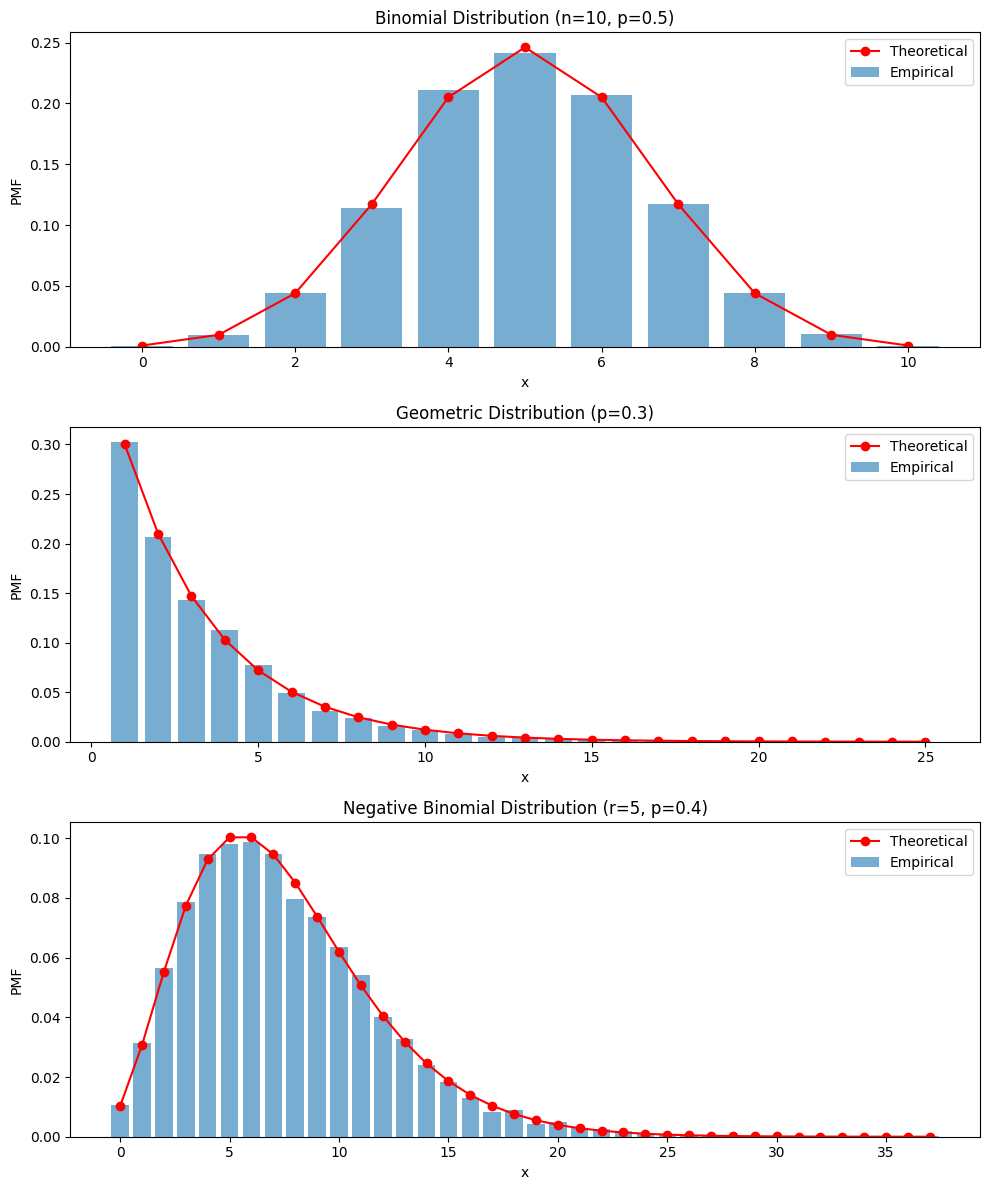

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, geom, nbinom

# Parameters
n, p = 10, 0.5           # Binomial
p_geom = 0.3             # Geometric
r, p_nbinom = 5, 0.4     # Negative Binomial

# Sample size
size = 10000

# Generate samples
binom_sample = np.random.binomial(n, p, size)
geom_sample = np.random.geometric(p_geom, size)
nbinom_sample = np.random.negative_binomial(r, p_nbinom, size)

# Define support ranges
x_binom = np.arange(0, n + 1)
x_geom = np.arange(1, np.max(geom_sample) + 1)
x_nbinom = np.arange(0, np.max(nbinom_sample) + 1)

# Empirical PMFs
binom_emp = np.bincount(binom_sample, minlength=n+1) / size
geom_emp = np.bincount(geom_sample)[1:] / size  # skip zero
nbinom_emp = np.bincount(nbinom_sample) / size

# Theoretical PMFs
binom_theo = binom.pmf(x_binom, n, p)
geom_theo = geom.pmf(x_geom, p_geom)
nbinom_theo = nbinom.pmf(x_nbinom, r, p_nbinom)

# Plotting
fig, axs = plt.subplots(3, 1, figsize=(10, 12))

# Binomial
axs[0].bar(x_binom, binom_emp, alpha=0.6, label='Empirical')
axs[0].plot(x_binom, binom_theo, 'ro-', label='Theoretical')
axs[0].set_title('Binomial Distribution (n=10, p=0.5)')
axs[0].set_xlabel('x')
axs[0].set_ylabel('PMF')
axs[0].legend()

# Geometric
axs[1].bar(x_geom, geom_emp, alpha=0.6, label='Empirical')
axs[1].plot(x_geom, geom_theo, 'ro-', label='Theoretical')
axs[1].set_title('Geometric Distribution (p=0.3)')
axs[1].set_xlabel('x')
axs[1].set_ylabel('PMF')
axs[1].legend()

# Negative Binomial
axs[2].bar(x_nbinom, nbinom_emp, alpha=0.6, label='Empirical')
axs[2].plot(x_nbinom, nbinom_theo, 'ro-', label='Theoretical')
axs[2].set_title('Negative Binomial Distribution (r=5, p=0.4)')
axs[2].set_xlabel('x')
axs[2].set_ylabel('PMF')
axs[2].legend()

plt.tight_layout()
plt.show()
